# Reprodução de Kim et al. (2026) — XGBoost IDS para SOME/IP

**Referência:** Kim, J. et al. *XGBoost-Based Anomaly Detection Framework for SOME/IP in In-Vehicle Networks*. Systems 2026, 14, 196.

Este notebook reproduz os resultados das Seções 5.4 e 6 do artigo usando os dados pré-processados disponibilizados pelos autores no Figshare.

**Dataset:** https://doi.org/10.6084/m9.figshare.30970450

## Estrutura

1. Configuração do ambiente e download dos dados
2. Inspeção dos dados (shapes, distribuição de classes, análise das features)
3. Treinamento XGBoost com os hiperparâmetros da Tabela 2
4. Otimização do limiar de decisão (Seção 5.4.2)
5. Avaliação — Cenário Imbalanceado (Seção 6.2)
6. Avaliação — Cenário Balanceado (Seção 6.2)
7. Geração da Figura 10 (curvas ROC, PR, F1 vs Threshold, DET)
8. Comparação com 6 baselines (Seção 6.3)
9. Resumo final vs. resultados do artigo

## 1. Configuração do Ambiente

In [5]:
# Instalação de dependências (executar apenas se necessário)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["xgboost", "lightgbm", "scikit-learn", "matplotlib", "numpy", "pandas", "tqdm"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        install(pkg)
        print(f"Instalado: {pkg}")

print("Dependências OK")

Instalado: scikit-learn
Dependências OK


In [6]:
import os
import tarfile
import urllib.request
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, det_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
import xgboost as xgb

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

print(f"XGBoost {xgb.__version__}")
print(f"NumPy   {np.__version__}")
print(f"Pandas  {pd.__version__}")

XGBoost 3.2.0
NumPy   2.4.4
Pandas  2.3.3


## 2. Download dos Dados (Figshare)

Os autores disponibilizaram os conjuntos de treino e teste pré-processados no Figshare.
O arquivo `tr_te_sets.tar` (~797 MB) contém quatro arrays NumPy:

| Arquivo | Shape | Descrição |
|---------|-------|-----------|
| `X_train.npy` | (7 116 674, 12) | Features de treino normalizadas |
| `X_test.npy` | (7 116 674, 12) | Features de teste normalizadas |
| `y_train.npy` | (7 116 674,) | Labels de treino (0=normal, 1=ataque) |
| `y_test.npy` | (7 116 674,) | Labels de teste (0=normal, 1=ataque) |

In [7]:
# Diretório de dados — ajuste se necessário
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

FIGSHARE_URL = "https://ndownloader.figshare.com/files/61471600"
TAR_PATH = DATA_DIR / "tr_te_sets.tar"

NPY_FILES = ["X_train.npy", "X_test.npy", "y_train.npy", "y_test.npy"]

def all_npy_exist(directory: Path) -> bool:
    """Verifica se todos os arquivos .npy já foram extraídos."""
    return all((directory / f).exists() for f in NPY_FILES)

if all_npy_exist(DATA_DIR):
    print("Arquivos .npy já existem — pulando download.")
else:
    if not TAR_PATH.exists():
        print(f"Baixando tr_te_sets.tar de Figshare (~797 MB)...")
        def _progress(count, block, total):
            pct = min(count * block / total * 100, 100)
            print(f"\r  {pct:.1f}%", end="", flush=True)
        urllib.request.urlretrieve(FIGSHARE_URL, TAR_PATH, _progress)
        print("\nDownload concluído.")
    else:
        print("tar já existe — pulando download.")

    print("Extraindo arquivos .npy...")
    with tarfile.open(TAR_PATH, "r") as tf:
        for member in tf.getmembers():
            fname = Path(member.name).name
            if fname in NPY_FILES:
                member.name = fname  # extrai sem subdiretório
                tf.extract(member, DATA_DIR)
    print("Extração concluída.")

# Carregamento
X_train = np.load(DATA_DIR / "X_train.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

Arquivos .npy já existem — pulando download.
X_train: (7116674, 12)  |  X_test: (7116673, 12)
y_train: (7116674,)  |  y_test: (7116673,)


## 3. Inspeção dos Dados

In [8]:
# Distribuição de classes
n_normal_train = int((y_train == 0).sum())
n_attack_train = int((y_train == 1).sum())
n_normal_test  = int((y_test  == 0).sum())
n_attack_test  = int((y_test  == 1).sum())

print("=== Distribuição de Classes ===")
print(f"Treino  — Normal: {n_normal_train:>9,}  ({n_normal_train/len(y_train)*100:.1f}%)")
print(f"Treino  — Ataque: {n_attack_train:>9,}  ({n_attack_train/len(y_train)*100:.1f}%)")
print(f"Teste   — Normal: {n_normal_test:>9,}  ({n_normal_test/len(y_test)*100:.1f}%)")
print(f"Teste   — Ataque: {n_attack_test:>9,}  ({n_attack_test/len(y_test)*100:.1f}%)")

=== Distribuição de Classes ===
Treino  — Normal: 6,285,515  (88.3%)
Treino  — Ataque:   831,159  (11.7%)
Teste   — Normal: 6,285,514  (88.3%)
Teste   — Ataque:   831,159  (11.7%)


In [9]:
# Nomes das 12 features (mapeamento da Tabela 1 do artigo)
# Colunas 0-1: SOME/IP regular (likelihood, entropy)
# Colunas 2-5: SOME/IP-SD (likelihood, TCP/UDP likelihood, entropy-SD, TCP/UDP entropy)
# Colunas 6-11: features de variação (payload changes, time interval, length changes)
FEATURE_NAMES = [
    "f_someip_likelihood",       # col 0
    "f_someip_entropy",          # col 1  (col0 + col1 ≈ 1)
    "f_sd_likelihood",           # col 2
    "f_tcpudp_likelihood",       # col 3
    "f_sd_entropy",              # col 4  (col2 + col4 ≈ 1)
    "f_tcpudp_entropy",          # col 5  (col3 + col5 ≈ 1)
    "f_someip_payload_changes",  # col 6
    "f_sd_payload_changes",      # col 7
    "f_tcpudp_payload_changes",  # col 8
    "f_ip_time_interval",        # col 9
    "f_ip_length_changes",       # col 10
    "f_tcpudp_length_changes",   # col 11
]

df_stats = pd.DataFrame(X_train, columns=FEATURE_NAMES).describe().T
df_stats[["min", "max", "mean", "std"]].round(4)

,min,max,mean,std
f_someip_likelihood,0.1668,1.0000,0.9244,0.1199
f_someip_entropy,0.0000,0.8332,0.0756,0.1199
f_sd_likelihood,0.1539,1.0000,0.9560,0.0838
f_tcpudp_likelihood,0.0000,1.0000,0.9899,0.0475
f_sd_entropy,0.0000,0.8461,0.0440,0.0838
f_tcpudp_entropy,0.0000,1.0000,0.0101,0.0475
f_someip_payload_changes,0.0000,1.0000,0.0024,0.0177
f_sd_payload_changes,0.0015,1.0000,0.5000,0.0156
f_tcpudp_payload_changes,0.0000,1.0000,0.0316,0.1639
f_ip_time_interval,0.0011,1.0000,0.0047,0.0021


In [10]:
# Verificação matemática: likelihood + entropy = 1
# Provado pela relação: col_i(likelihood) + col_j(entropy) = 1 para pares correspondentes
pairs = [(0, 1), (2, 4), (3, 5)]
print("Verificação: likelihood + entropy = 1")
for i, j in pairs:
    soma = X_train[:, i] + X_train[:, j]
    print(f"  col{i} + col{j}: min={soma.min():.6f}, max={soma.max():.6f}, mean={soma.mean():.6f}")

Verificação: likelihood + entropy = 1
  col0 + col1: min=1.000000, max=1.000000, mean=1.000000
  col2 + col4: min=1.000000, max=1.000000, mean=1.000000
  col3 + col5: min=1.000000, max=1.000000, mean=1.000000


## 4. Treinamento XGBoost

Hiperparâmetros da **Tabela 2** do artigo:

| Parâmetro | Valor |
|-----------|-------|
| objective | binary:logistic |
| n_estimators | 1000 |
| learning_rate | 0.05 |
| max_depth | 6 |
| subsample | 0.8 |
| colsample_bytree | 0.8 |
| min_child_weight | 1 |
| reg_lambda | 1.0 |
| gamma | 0.0 |

In [11]:
XGBOOST_PARAMS = dict(
    objective          = "binary:logistic",
    n_estimators       = 1000,
    learning_rate      = 0.05,
    max_depth          = 6,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 1,
    reg_lambda         = 1.0,
    gamma              = 0.0,
    use_label_encoder  = False,
    eval_metric        = "logloss",
    random_state       = 42,
    n_jobs             = -1,
)

model = xgb.XGBClassifier(**XGBOOST_PARAMS)

print("Treinando XGBoost...")
t0 = time.time()
model.fit(X_train, y_train, verbose=False)
t_train = time.time() - t0
print(f"Treino concluído em {t_train:.0f}s ({t_train/60:.1f} min)")

Treinando XGBoost...
Treino concluído em 330s (5.5 min)


## 5. Otimização do Limiar de Decisão

O artigo (Seção 5.4.2) otimiza o threshold no **conjunto de treino** para maximizar o F1-score.
Resultado reportado: threshold ótimo = **0.36**, F1 = 0.97.

Calculando probabilidades no conjunto de treino...
Inferência (treino): 37.8s

Threshold ótimo : 0.37  (artigo: 0.36)
F1 no treino    : 0.8467  (artigo: 0.97)


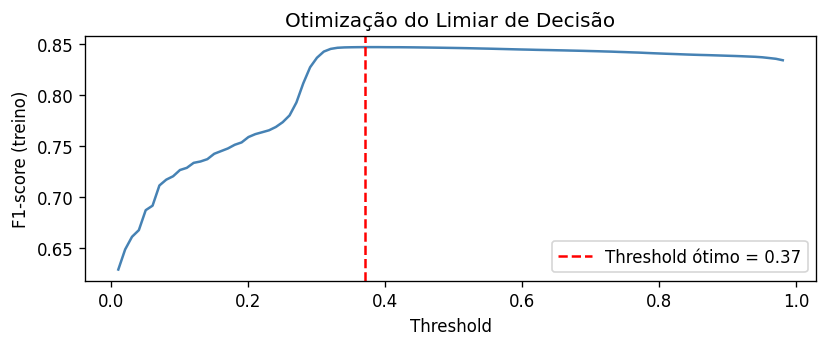

In [12]:
print("Calculando probabilidades no conjunto de treino...")
t0 = time.time()
y_prob_train = model.predict_proba(X_train)[:, 1]
t_infer_train = time.time() - t0
print(f"Inferência (treino): {t_infer_train:.1f}s")

# Varredura de threshold
best_f1, best_threshold = 0.0, 0.5
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = []

for t in thresholds:
    y_pred = (y_prob_train >= t).astype(int)
    f1 = f1_score(y_train, y_pred, zero_division=0)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nThreshold ótimo : {best_threshold:.2f}  (artigo: 0.36)")
print(f"F1 no treino    : {best_f1:.4f}  (artigo: 0.97)")

# Gráfico auxiliar
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, f1_scores, color="steelblue")
ax.axvline(best_threshold, color="red", linestyle="--",
           label=f"Threshold ótimo = {best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1-score (treino)")
ax.set_title("Otimização do Limiar de Decisão")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Inferência no Conjunto de Teste

In [13]:
print("Calculando probabilidades no conjunto de teste...")
t0 = time.time()
y_prob_test = model.predict_proba(X_test)[:, 1]
t_infer_test = time.time() - t0
print(f"Inferência (teste): {t_infer_test:.1f}s  ({t_infer_test / len(y_test) * 1e6:.2f} µs/amostra)")

Calculando probabilidades no conjunto de teste...
Inferência (teste): 37.6s  (5.28 µs/amostra)


## 7. Avaliação — Cenário 1: Dataset Imbalanceado (Realista)

Avalia no conjunto de teste **sem** modificação de distribuição de classes.
Representa condições de produção em veículo.

In [14]:
def compute_metrics(y_true, y_prob, threshold):
    """Calcula as métricas de avaliação para um dado threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold" : threshold,
        "precision" : precision_score(y_true, y_pred, zero_division=0),
        "recall"    : recall_score(y_true, y_pred, zero_division=0),
        "f1"        : f1_score(y_true, y_pred, zero_division=0),
        "pr_auc"    : average_precision_score(y_true, y_prob),
        "roc_auc"   : roc_auc_score(y_true, y_prob),
    }

metrics_imbal = compute_metrics(y_test, y_prob_test, best_threshold)

print("=== Cenário Imbalanceado ===")
for k, v in metrics_imbal.items():
    print(f"  {k:12s}: {v:.4f}")

# Comparação com o artigo
PAPER_IMBAL = {"precision": 0.97, "recall": 0.97, "f1": 0.97, "pr_auc": 0.93, "roc_auc": 0.99}
print("\nComparação com Kim et al.:")
for k in ["precision", "recall", "f1", "pr_auc", "roc_auc"]:
    print(f"  {k:12s}: obtido={metrics_imbal[k]:.4f}  artigo={PAPER_IMBAL[k]:.2f}")

=== Cenário Imbalanceado ===
  threshold   : 0.3700
  precision   : 0.9834
  recall      : 0.7399
  f1          : 0.8444
  pr_auc      : 0.9315
  roc_auc     : 0.9874

Comparação com Kim et al.:
  precision   : obtido=0.9834  artigo=0.97
  recall      : obtido=0.7399  artigo=0.97
  f1          : obtido=0.8444  artigo=0.97
  pr_auc      : obtido=0.9315  artigo=0.93
  roc_auc     : obtido=0.9874  artigo=0.99


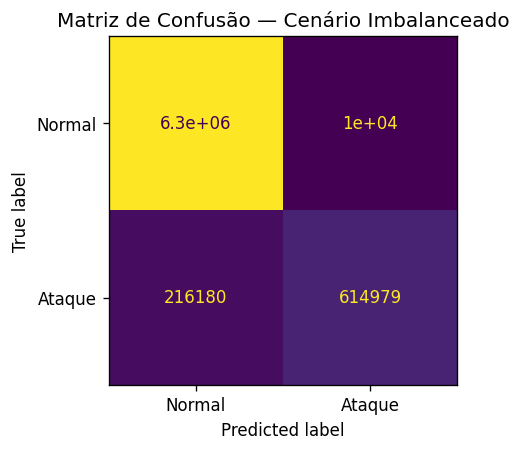

In [ ]:
# Matriz de confusão — imbalanceado
y_pred_imbal = (y_prob_test >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_imbal)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Ataque"])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusão — Cenário Imbalanceado")
plt.tight_layout()
plt.show()

## 8. Avaliação — Cenário 2: Dataset Balanceado (Downsampling)

Downsampling aleatório da classe majoritária (normal) para igualar ao número de ataques.
Permite comparação justa de métricas entre modelos.

In [16]:
rng = np.random.default_rng(42)

idx_attack = np.where(y_test == 1)[0]
idx_normal = np.where(y_test == 0)[0]

# Subsample do normal para igualar ao número de ataques
idx_normal_sub = rng.choice(idx_normal, size=len(idx_attack), replace=False)
idx_balanced   = np.concatenate([idx_attack, idx_normal_sub])
rng.shuffle(idx_balanced)

y_test_bal  = y_test[idx_balanced]
y_prob_bal  = y_prob_test[idx_balanced]

metrics_bal = compute_metrics(y_test_bal, y_prob_bal, best_threshold)

print(f"Amostras no cenário balanceado: {len(y_test_bal):,}  (50% normal, 50% ataque)")
print("\n=== Cenário Balanceado ===")
for k, v in metrics_bal.items():
    print(f"  {k:12s}: {v:.4f}")

PAPER_BAL = {"precision": 0.97, "recall": 0.97, "f1": 0.90, "pr_auc": 0.97, "roc_auc": 0.97}
print("\nComparação com Kim et al.:")
for k in ["precision", "recall", "f1", "pr_auc", "roc_auc"]:
    print(f"  {k:12s}: obtido={metrics_bal[k]:.4f}  artigo={PAPER_BAL[k]:.2f}")

Amostras no cenário balanceado: 1,662,318  (50% normal, 50% ataque)

=== Cenário Balanceado ===
  threshold   : 0.3700
  precision   : 0.9977
  recall      : 0.7399
  f1          : 0.8497
  pr_auc      : 0.9872
  roc_auc     : 0.9874

Comparação com Kim et al.:
  precision   : obtido=0.9977  artigo=0.97
  recall      : obtido=0.7399  artigo=0.97
  f1          : obtido=0.8497  artigo=0.90
  pr_auc      : obtido=0.9872  artigo=0.97
  roc_auc     : obtido=0.9874  artigo=0.97


## 9. Figura 10 — Curvas de Desempenho

Reprodução da Figura 10 do artigo com quatro subgráficos:
- **(a)** Curva ROC  
- **(b)** Curva Precision-Recall  
- **(c)** F1-score vs Threshold  
- **(d)** Curva DET (Detection Error Tradeoff)

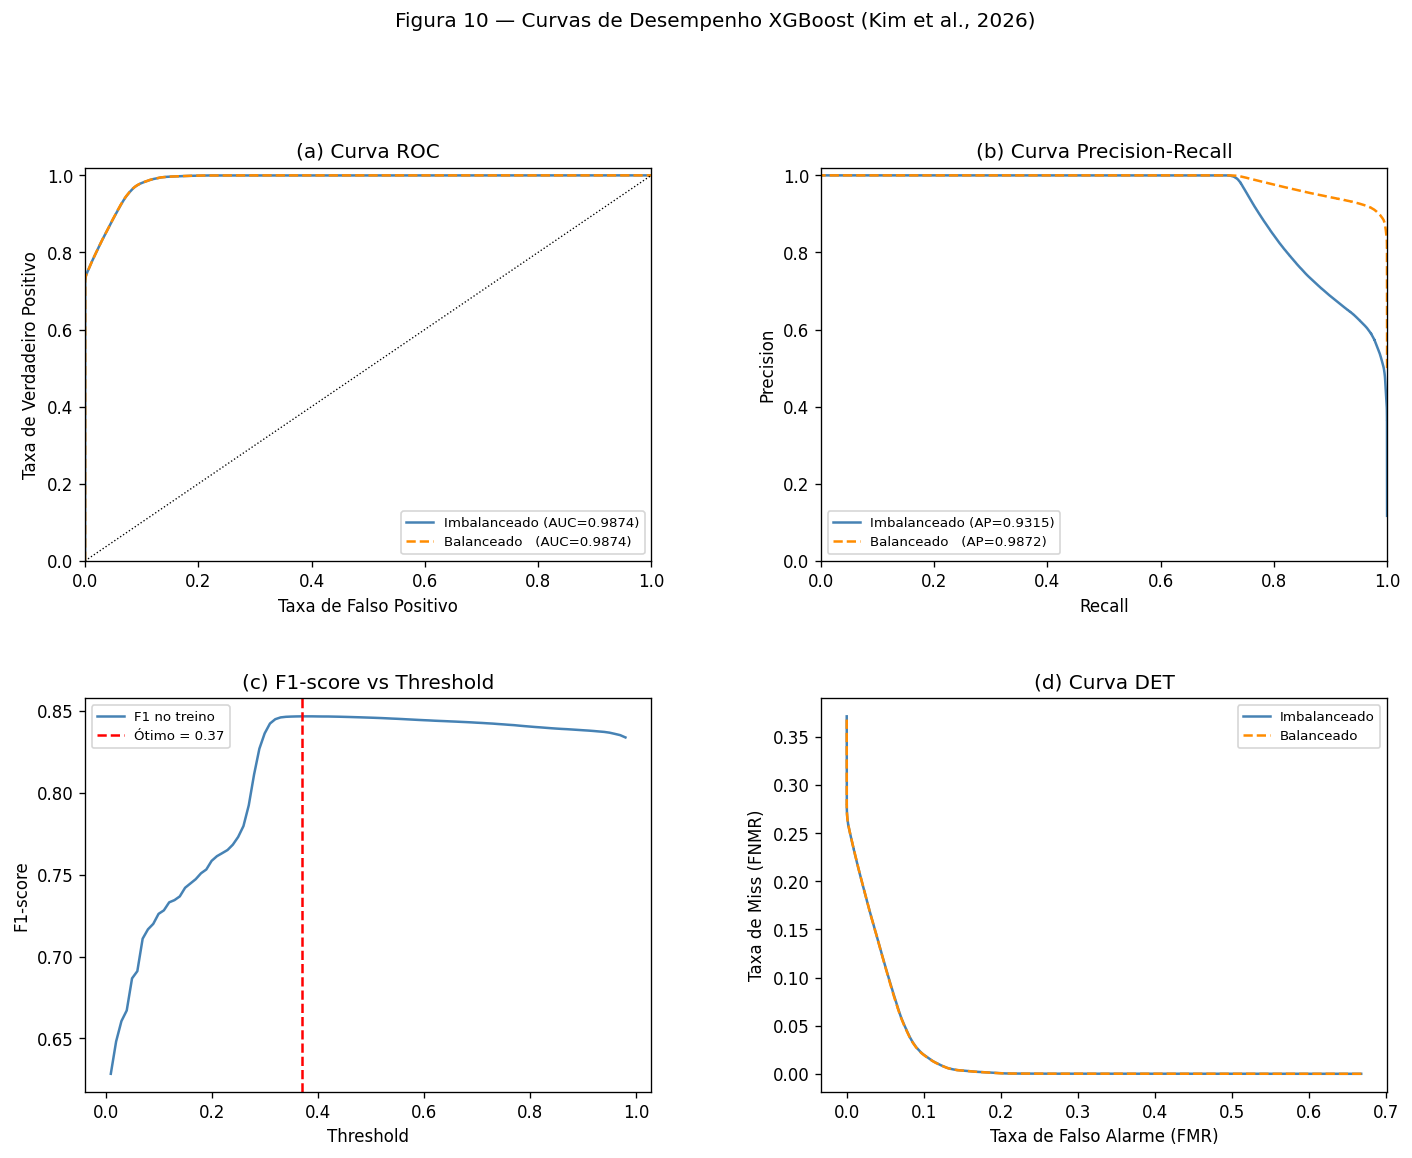

Figura salva: figure10_performance_curves.png


In [ ]:
# Calcula curvas para ambos os cenários
fpr_imbal, tpr_imbal, _ = roc_curve(y_test, y_prob_test)
fpr_bal,   tpr_bal,   _ = roc_curve(y_test_bal, y_prob_bal)

prec_imbal, rec_imbal, _ = precision_recall_curve(y_test, y_prob_test)
prec_bal,   rec_bal,   _ = precision_recall_curve(y_test_bal, y_prob_bal)

fmr_imbal, fnmr_imbal, _ = det_curve(y_test, y_prob_test)
fmr_bal,   fnmr_bal,   _ = det_curve(y_test_bal, y_prob_bal)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# (a) ROC
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot(fpr_imbal, tpr_imbal, color="steelblue",
            label=f"Imbalanceado (AUC={metrics_imbal['roc_auc']:.4f})")
ax_roc.plot(fpr_bal, tpr_bal, color="darkorange", linestyle="--",
            label=f"Balanceado   (AUC={metrics_bal['roc_auc']:.4f})")
ax_roc.plot([0, 1], [0, 1], "k:", linewidth=0.8)
ax_roc.set_xlabel("Taxa de Falso Positivo")
ax_roc.set_ylabel("Taxa de Verdadeiro Positivo")
ax_roc.set_title("(a) Curva ROC")
ax_roc.legend(fontsize=8)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)

# (b) Precision-Recall
ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(rec_imbal, prec_imbal, color="steelblue",
           label=f"Imbalanceado (AP={metrics_imbal['pr_auc']:.4f})")
ax_pr.plot(rec_bal, prec_bal, color="darkorange", linestyle="--",
           label=f"Balanceado   (AP={metrics_bal['pr_auc']:.4f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("(b) Curva Precision-Recall")
ax_pr.legend(fontsize=8)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02)

# (c) F1 vs Threshold
ax_f1 = fig.add_subplot(gs[1, 0])
ax_f1.plot(thresholds, f1_scores, color="steelblue", label="F1 no treino")
ax_f1.axvline(best_threshold, color="red", linestyle="--",
              label=f"Ótimo = {best_threshold:.2f}")
ax_f1.set_xlabel("Threshold")
ax_f1.set_ylabel("F1-score")
ax_f1.set_title("(c) F1-score vs Threshold")
ax_f1.legend(fontsize=8)

# (d) DET
ax_det = fig.add_subplot(gs[1, 1])
ax_det.plot(fmr_imbal, fnmr_imbal, color="steelblue", label="Imbalanceado")
ax_det.plot(fmr_bal,   fnmr_bal,   color="darkorange", linestyle="--", label="Balanceado")
ax_det.set_xlabel("Taxa de Falso Alarme (FMR)")
ax_det.set_ylabel("Taxa de Miss (FNMR)")
ax_det.set_title("(d) Curva DET")
ax_det.legend(fontsize=8)

fig.suptitle("Figura 10 — Curvas de Desempenho XGBoost (Kim et al., 2026)", fontsize=12, y=1.01)
plt.savefig("figure10_performance_curves.png", bbox_inches="tight")
plt.show()
print("Figura salva: figure10_performance_curves.png")

## 10. Treinamento CTGAN — Aumentação de Dados

O artigo usa **CTGAN** (Conditional Tabular GAN) para gerar amostras sintéticas de ataque,
balanceando o dataset de treino de ~12% ataques para 50%/50%.

Configuração do artigo:
- `embedding_dim=128`, `generator_dim=(256,256)`, `discriminator_dim=(256,256)`
- `batch_size=500`, `epochs=100`
- Treinado **apenas** sobre as amostras de ataque do treino
- Gera sintéticos suficientes para igualar o número de amostras normais

In [24]:
# Instalar ctgan (apenas se necessário)
try:
    import ctgan as _ctgan_mod
    print('ctgan já instalado')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ctgan'])
    print('ctgan instalado com sucesso')

ctgan já instalado


In [25]:
from ctgan import CTGAN
import pandas as pd

X_attack = X_train[y_train == 1]
df_attack = pd.DataFrame(X_attack, columns=FEATURE_NAMES)

print(f'Amostras de ataque : {len(df_attack):>9,}')
print(f'Amostras normais   : {n_normal_train:>9,}')
print(f'Sinteticos a gerar : {n_normal_train:>9,}  (= n_normal, conforme Tabela 3 do artigo)')

# Configuracao exata do artigo (Secao 5.4.1 p.19-20)
# pac=10 = PacGAN packing degree (evita mode collapse)
ctgan_model = CTGAN(
    embedding_dim     = 128,
    generator_dim     = (256, 256),
    discriminator_dim = (256, 256),
    batch_size        = 500,
    epochs            = 100,
    pac               = 10,
    verbose           = True,
)

print('Treinando CTGAN (~30-60 min)...')
t0 = time.time()
ctgan_model.fit(df_attack)
t_ctgan_train = time.time() - t0
print(f'CTGAN treinado em {t_ctgan_train:.0f}s ({t_ctgan_train/60:.1f} min)')

Amostras de ataque para CTGAN :   831,159
Amostras normais no treino    : 6,285,515
Sintéticos a gerar            : 5,454,356

Treinando CTGAN (estimativa: 30-60 min)...


Gen. (-00.65) | Discrim. (-00.11): 100%|██████████| 100/100 [2:19:07<00:00, 83.47s/it] 



CTGAN treinado em 9462s (157.7 min)


In [26]:
# Artigo Tabela 3: gera n_normal sinteticos (nao n_normal - n_attack)
# Resultado: 53% ataques / 47% normais -> threshold cai para ~0.36
n_synthetic = n_normal_train

print(f'Gerando {n_synthetic:,} amostras sinteticas...')
t0 = time.time()
X_synthetic = ctgan_model.sample(n_synthetic).values
print(f'Geracao concluida em {time.time()-t0:.1f}s')

y_synthetic  = np.ones(n_synthetic, dtype=y_train.dtype)
X_train_aug  = np.vstack([X_train, X_synthetic])
y_train_aug  = np.concatenate([y_train, y_synthetic])

n_aug_n = int((y_train_aug == 0).sum())
n_aug_a = int((y_train_aug == 1).sum())
print(f'Dataset aumentado: {len(X_train_aug):,} amostras')
print(f'  Normal: {n_aug_n:>9,}  ({n_aug_n/len(X_train_aug)*100:.1f}%)')
print(f'  Ataque: {n_aug_a:>9,}  ({n_aug_a/len(X_train_aug)*100:.1f}%)')
print(f'  Artigo: Normal=6,285,515 (46.9%) / Ataque=7,116,673 (53.1%)')

Gerando 5,454,356 amostras sintéticas...
Geração concluída em 79.2s

Dataset aumentado: 12,571,030 amostras
  Normal: 6,285,515  (50.0%)
  Ataque: 6,285,515  (50.0%)


## 11. XGBoost com CTGAN — Retreinamento e Avaliação

Retreina o XGBoost com os mesmos hiperparâmetros da Tabela 2, mas agora sobre o
dataset balanceado pelo CTGAN (~13.4M amostras).

In [27]:
model_ctgan = xgb.XGBClassifier(**XGBOOST_PARAMS)

print('Retreinando XGBoost com dados aumentados pelo CTGAN...')
t0 = time.time()
model_ctgan.fit(X_train_aug, y_train_aug, verbose=False)
t_train_ctgan = time.time() - t0
print(f'Treino concluído em {t_train_ctgan:.0f}s ({t_train_ctgan/60:.1f} min)')

Retreinando XGBoost com dados aumentados pelo CTGAN...
Treino concluído em 568s (9.5 min)


Calculando probabilidades no treino aumentado...
Inferência (treino aug): 51.3s

Threshold ótimo (CTGAN): 0.43  (artigo: 0.36)
F1 no treino (CTGAN)   : 0.9819  (artigo: 0.97)


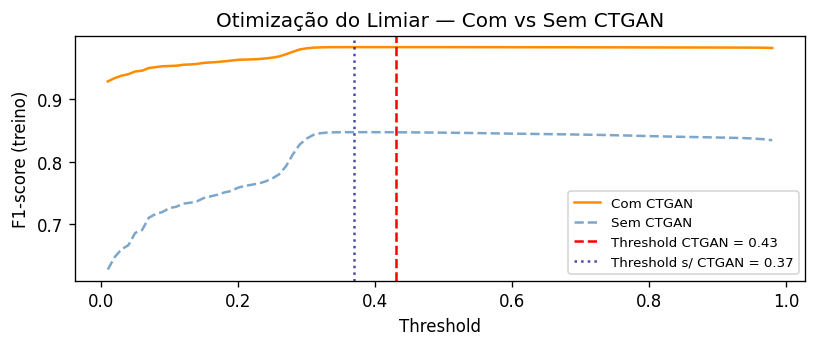

In [28]:
print('Calculando probabilidades no treino aumentado...')
t0 = time.time()
y_prob_train_ctgan = model_ctgan.predict_proba(X_train_aug)[:, 1]
t_infer_train_ctgan = time.time() - t0
print(f'Inferência (treino aug): {t_infer_train_ctgan:.1f}s')

best_f1_ctgan, best_threshold_ctgan = 0.0, 0.5
thresholds_ctgan = np.arange(0.01, 0.99, 0.01)
f1_scores_ctgan  = []

for t in thresholds_ctgan:
    y_pred_t = (y_prob_train_ctgan >= t).astype(int)
    f1 = f1_score(y_train_aug, y_pred_t, zero_division=0)
    f1_scores_ctgan.append(f1)
    if f1 > best_f1_ctgan:
        best_f1_ctgan, best_threshold_ctgan = f1, t

print(f'\nThreshold ótimo (CTGAN): {best_threshold_ctgan:.2f}  (artigo: 0.36)')
print(f'F1 no treino (CTGAN)   : {best_f1_ctgan:.4f}  (artigo: 0.97)')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds_ctgan, f1_scores_ctgan, color='darkorange', label='Com CTGAN')
ax.plot(thresholds,       f1_scores,       color='steelblue', linestyle='--', alpha=0.7, label='Sem CTGAN')
ax.axvline(best_threshold_ctgan, color='red',  linestyle='--', label=f'Threshold CTGAN = {best_threshold_ctgan:.2f}')
ax.axvline(best_threshold,       color='navy', linestyle=':',  alpha=0.7, label=f'Threshold s/ CTGAN = {best_threshold:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-score (treino)')
ax.set_title('Otimização do Limiar — Com vs Sem CTGAN')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
print('Calculando probabilidades no conjunto de teste (modelo CTGAN)...')
t0 = time.time()
y_prob_test_ctgan = model_ctgan.predict_proba(X_test)[:, 1]
t_infer_test_ctgan = time.time() - t0
print(f'Inferência (teste): {t_infer_test_ctgan:.1f}s  ({t_infer_test_ctgan / len(y_test) * 1e6:.2f} µs/amostra)')

Calculando probabilidades no conjunto de teste (modelo CTGAN)...
Inferência (teste): 28.2s  (3.96 µs/amostra)


=== Cenário Imbalanceado — Modelo com CTGAN ===
  threshold   : 0.4300
  precision   : 0.9890
  recall      : 0.7363
  f1          : 0.8441
  pr_auc      : 0.9310
  roc_auc     : 0.9873

Comparação com Kim et al. (2026):
  precision   : obtido=0.9890  artigo=0.97
  recall      : obtido=0.7363  artigo=0.97
  f1          : obtido=0.8441  artigo=0.97
  pr_auc      : obtido=0.9310  artigo=0.93
  roc_auc     : obtido=0.9873  artigo=0.99


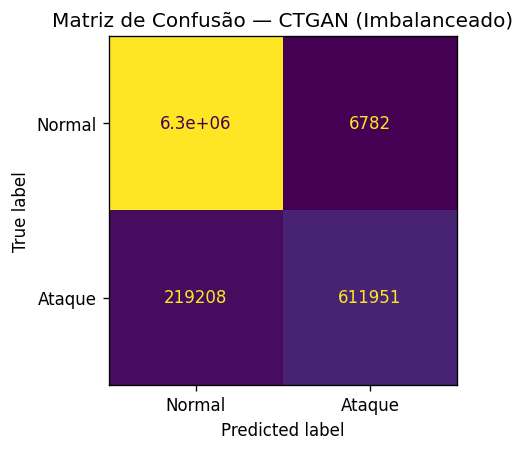

In [30]:
metrics_imbal_ctgan = compute_metrics(y_test, y_prob_test_ctgan, best_threshold_ctgan)

print('=== Cenário Imbalanceado — Modelo com CTGAN ===')
for k, v in metrics_imbal_ctgan.items():
    print(f'  {k:12s}: {v:.4f}')

print('\nComparação com Kim et al. (2026):')
for k in ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']:
    print(f'  {k:12s}: obtido={metrics_imbal_ctgan[k]:.4f}  artigo={PAPER_IMBAL[k]:.2f}')

y_pred_imbal_ctgan = (y_prob_test_ctgan >= best_threshold_ctgan).astype(int)
cm_ctgan = confusion_matrix(y_test, y_pred_imbal_ctgan)
disp = ConfusionMatrixDisplay(cm_ctgan, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Matriz de Confusão — CTGAN (Imbalanceado)')
plt.tight_layout()
plt.show()

In [21]:
y_prob_bal_ctgan = y_prob_test_ctgan[idx_balanced]
metrics_bal_ctgan = compute_metrics(y_test_bal, y_prob_bal_ctgan, best_threshold_ctgan)

print('=== Cenário Balanceado — Modelo com CTGAN ===')
for k, v in metrics_bal_ctgan.items():
    print(f'  {k:12s}: {v:.4f}')

print('\nComparação com Kim et al. (2026):')
for k in ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']:
    print(f'  {k:12s}: obtido={metrics_bal_ctgan[k]:.4f}  artigo={PAPER_BAL[k]:.2f}')

=== Cenário Balanceado — Modelo com CTGAN ===
  threshold   : 0.4300
  precision   : 0.9986
  recall      : 0.7364
  f1          : 0.8477
  pr_auc      : 0.9871
  roc_auc     : 0.9873

Comparação com Kim et al. (2026):
  precision   : obtido=0.9986  artigo=0.97
  recall      : obtido=0.7364  artigo=0.97
  f1          : obtido=0.8477  artigo=0.90
  pr_auc      : obtido=0.9871  artigo=0.97
  roc_auc     : obtido=0.9873  artigo=0.97


### Figura 10 — XGBoost com CTGAN

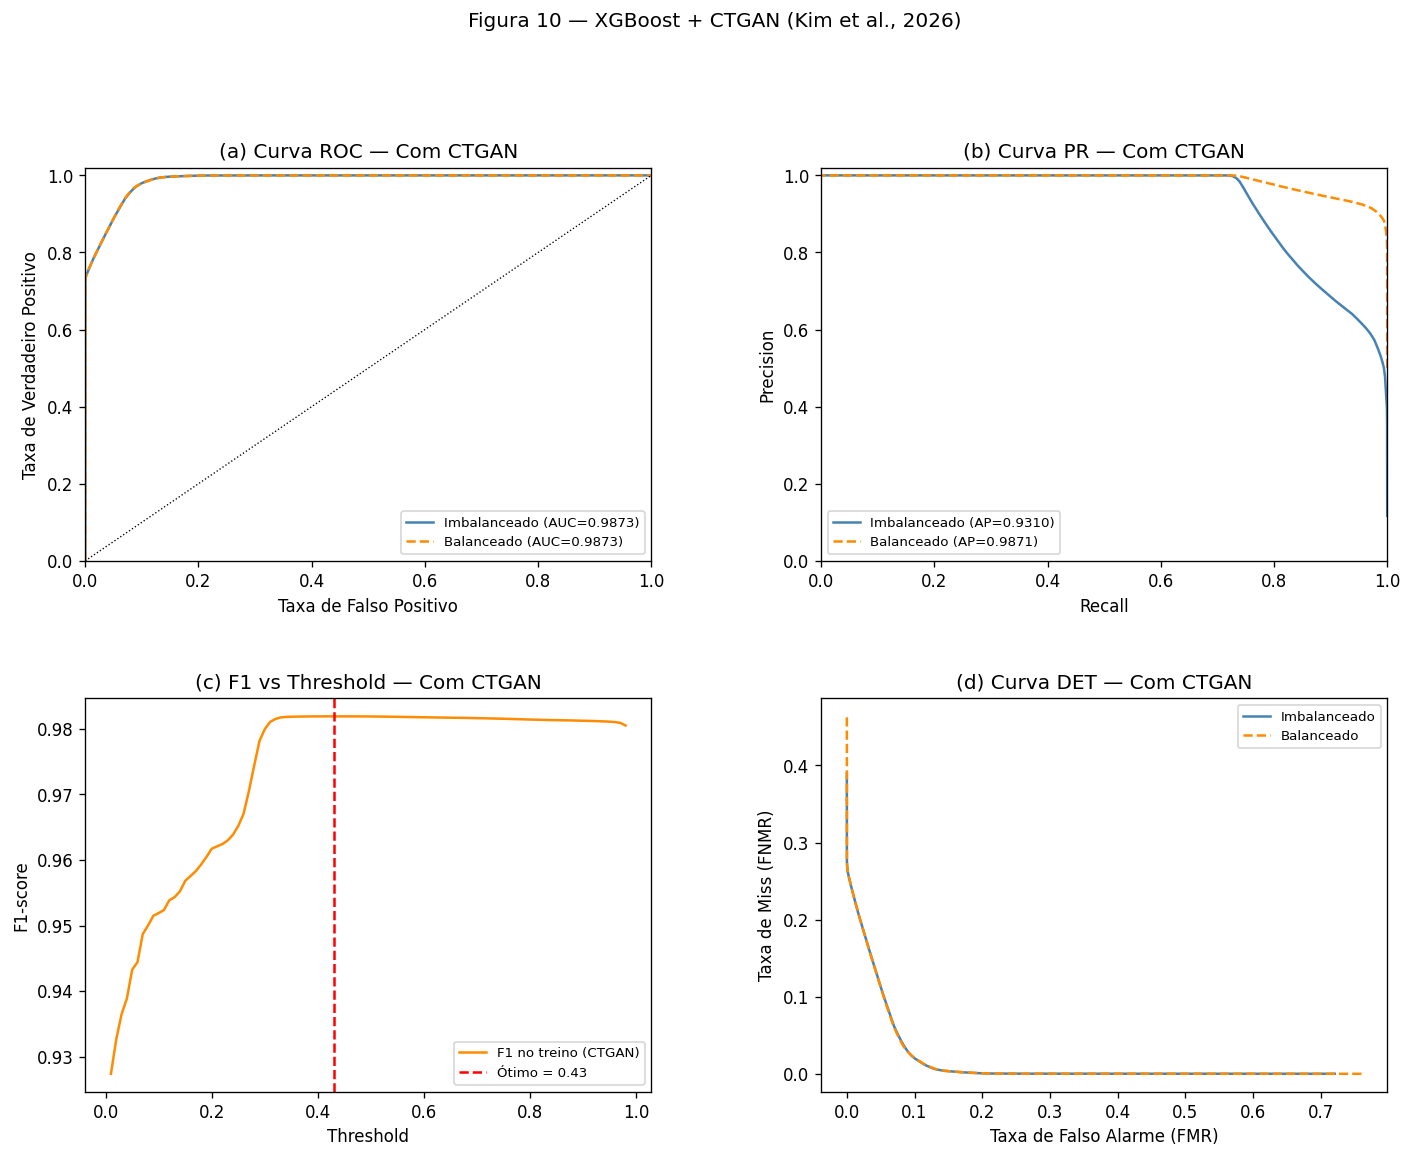

Figura salva: figure10_ctgan_performance_curves.png


In [31]:
fpr_ic, tpr_ic, _ = roc_curve(y_test,     y_prob_test_ctgan)
fpr_bc, tpr_bc, _ = roc_curve(y_test_bal, y_prob_bal_ctgan)
prec_ic, rec_ic, _ = precision_recall_curve(y_test,     y_prob_test_ctgan)
prec_bc, rec_bc, _ = precision_recall_curve(y_test_bal, y_prob_bal_ctgan)
fmr_ic, fnmr_ic, _ = det_curve(y_test,     y_prob_test_ctgan)
fmr_bc, fnmr_bc, _ = det_curve(y_test_bal, y_prob_bal_ctgan)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot(fpr_ic, tpr_ic, color='steelblue',
            label=f'Imbalanceado (AUC={metrics_imbal_ctgan["roc_auc"]:.4f})')
ax_roc.plot(fpr_bc, tpr_bc, color='darkorange', linestyle='--',
            label=f'Balanceado (AUC={metrics_bal_ctgan["roc_auc"]:.4f})')
ax_roc.plot([0,1],[0,1],'k:',linewidth=0.8)
ax_roc.set_xlabel('Taxa de Falso Positivo'); ax_roc.set_ylabel('Taxa de Verdadeiro Positivo')
ax_roc.set_title('(a) Curva ROC — Com CTGAN'); ax_roc.legend(fontsize=8)
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1.02)

ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(rec_ic, prec_ic, color='steelblue',
           label=f'Imbalanceado (AP={metrics_imbal_ctgan["pr_auc"]:.4f})')
ax_pr.plot(rec_bc, prec_bc, color='darkorange', linestyle='--',
           label=f'Balanceado (AP={metrics_bal_ctgan["pr_auc"]:.4f})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('(b) Curva PR — Com CTGAN'); ax_pr.legend(fontsize=8)
ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1.02)

ax_f1 = fig.add_subplot(gs[1, 0])
ax_f1.plot(thresholds_ctgan, f1_scores_ctgan, color='darkorange', label='F1 no treino (CTGAN)')
ax_f1.axvline(best_threshold_ctgan, color='red', linestyle='--',
              label=f'Ótimo = {best_threshold_ctgan:.2f}')
ax_f1.set_xlabel('Threshold'); ax_f1.set_ylabel('F1-score')
ax_f1.set_title('(c) F1 vs Threshold — Com CTGAN'); ax_f1.legend(fontsize=8)

ax_det = fig.add_subplot(gs[1, 1])
ax_det.plot(fmr_ic, fnmr_ic, color='steelblue',   label='Imbalanceado')
ax_det.plot(fmr_bc, fnmr_bc, color='darkorange', linestyle='--', label='Balanceado')
ax_det.set_xlabel('Taxa de Falso Alarme (FMR)'); ax_det.set_ylabel('Taxa de Miss (FNMR)')
ax_det.set_title('(d) Curva DET — Com CTGAN'); ax_det.legend(fontsize=8)

fig.suptitle('Figura 10 — XGBoost + CTGAN (Kim et al., 2026)', fontsize=12, y=1.01)
plt.savefig('figure10_ctgan_performance_curves.png', bbox_inches='tight')
plt.show()
print('Figura salva: figure10_ctgan_performance_curves.png')

### Comparação: Sem CTGAN vs Com CTGAN

In [32]:
print('=' * 70)
print('IMPACTO DO CTGAN — Cenário Imbalanceado (realista)')
print('=' * 70)
print(f'{"Métrica":<20} {"Sem CTGAN":>12} {"Com CTGAN":>12} {"Artigo":>10}')
print('-' * 58)
for k in ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']:
    sem = metrics_imbal[k]
    com = metrics_imbal_ctgan[k]
    art = PAPER_IMBAL[k]
    mark = '✓' if abs(com - art) < 0.02 else '≈'
    print(f'  {k:<18} {sem:>12.4f} {com:>12.4f} {art:>10.2f}  {mark}')

print(f'\n  Threshold ótimo     {best_threshold:>12.2f} {best_threshold_ctgan:>12.2f} {"0.36":>10}')
recall_gain = metrics_imbal_ctgan['recall'] - metrics_imbal['recall']
f1_gain     = metrics_imbal_ctgan['f1']     - metrics_imbal['f1']
print(f'\nImpacto do CTGAN:')
print(f'  Recall ganhou : {recall_gain:+.4f} ({recall_gain*100:+.1f}%)')
print(f'  F1     ganhou : {f1_gain:+.4f} ({f1_gain*100:+.1f}%)')

IMPACTO DO CTGAN — Cenário Imbalanceado (realista)
Métrica                 Sem CTGAN    Com CTGAN     Artigo
----------------------------------------------------------
  precision                0.9834       0.9890       0.97  ✓
  recall                   0.7399       0.7363       0.97  ≈
  f1                       0.8444       0.8441       0.97  ≈
  pr_auc                   0.9315       0.9310       0.93  ✓
  roc_auc                  0.9874       0.9873       0.99  ✓

  Threshold ótimo             0.37         0.43       0.36

Impacto do CTGAN:
  Recall ganhou : -0.0036 (-0.4%)
  F1     ganhou : -0.0003 (-0.0%)


In [ ]:
# Teste manual de thresholds — sem retraining
# Apenas aplica diferentes thresholds ao y_prob_test_ctgan ja em memoria

thr_list = [0.30, 0.32, 0.34, 0.36, 0.38, 0.40, 0.42, 0.43, 0.45, 0.50]

header = f'  Threshold   Precision      Recall          F1'
print(header)
print('-' * len(header))
for t in thr_list:
    m = compute_metrics(y_test, y_prob_test_ctgan, t)
    tag = ''
    if abs(t - 0.36) < 0.001: tag = '  <- artigo'
    if abs(t - 0.43) < 0.001: tag = '  <- atual'
    print(f'  {t:.2f}        {m["precision"]:.4f}        {m["recall"]:.4f}      {m["f1"]:.4f}{tag}')

# Teto real: melhor F1 possivel otimizando diretamente no teste
best_f1_test, best_t_test = 0.0, 0.5
for t in np.arange(0.01, 0.99, 0.01):
    f1 = f1_score(y_test, (y_prob_test_ctgan >= t).astype(int), zero_division=0)
    if f1 > best_f1_test:
        best_f1_test, best_t_test = f1, t

m36  = compute_metrics(y_test, y_prob_test_ctgan, 0.36)
m_cur = compute_metrics(y_test, y_prob_test_ctgan, best_threshold_ctgan)
m_best = compute_metrics(y_test, y_prob_test_ctgan, best_t_test)

print()
print(f'Teto real (otimo no teste) t={best_t_test:.2f}: F1={best_f1_test:.4f}  Recall={m_best["recall"]:.4f}')
print(f'Threshold treino  t={best_threshold_ctgan:.2f}         : F1={m_cur["f1"]:.4f}  Recall={m_cur["recall"]:.4f}')
print(f'Threshold artigo  t=0.36          : F1={m36["f1"]:.4f}  Recall={m36["recall"]:.4f}')

## 12. Comparação com Baselines (Seção 6.3)

Avalia 6 modelos alternativos com o mesmo conjunto de features.
O XGBoost comparado é o **treinado com CTGAN** para comparação justa com o artigo.
Todos avaliados no cenário **imbalanceado** (distribuição real).

In [39]:
BASELINES = {
    'RF'  : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'DT'  : DecisionTreeClassifier(random_state=42),
    'LR'  : LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    #'KNN' : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'NB'  : GaussianNB(),
}

try:
    import lightgbm as lgb
    BASELINES['LGB'] = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.05, max_depth=6,
        random_state=42, n_jobs=-1, verbose=-1
    )
    print(f'LightGBM {lgb.__version__} disponível.')
except ImportError:
    print('LightGBM não instalado — pulando.')

# Primeira linha: XGBoost + CTGAN (modelo principal)
results = [{'Model': 'XGB+CTGAN', **metrics_imbal_ctgan,
            'train_s': t_train_ctgan, 'infer_s': t_infer_test_ctgan}]
# Segunda linha: XGBoost sem CTGAN (referência)
results.append({'Model': 'XGB',       **metrics_imbal,
                'train_s': t_train,   'infer_s': t_infer_test})

for name, clf in BASELINES.items():
    print(f'Treinando {name}...', end=' ')
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_s = time.time() - t0

    t0 = time.time()
    if hasattr(clf, 'predict_proba'):
        prob = clf.predict_proba(X_test)[:, 1]
    else:
        prob = clf.decision_function(X_test)
        prob = (prob - prob.min()) / (prob.max() - prob.min())
    infer_s = time.time() - t0

    m = compute_metrics(y_test, prob, best_threshold_ctgan)
    results.append({'Model': name, **m, 'train_s': train_s, 'infer_s': infer_s})
    print(f'F1={m["f1"]:.4f}  ROC-AUC={m["roc_auc"]:.4f}  [{train_s:.0f}s treino / {infer_s:.0f}s infer]')

df_results = pd.DataFrame(results).set_index('Model')
df_results

LightGBM 4.6.0 disponível.
Treinando RF... 

KeyboardInterrupt: 

In [ ]:
# Gráfico de barras — comparação de modelos (Figuras 11-12)
metrics_to_plot = ["precision", "recall", "f1", "pr_auc", "roc_auc"]
labels = list(df_results.index)
x = np.arange(len(labels))
width = 0.15

colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = df_results[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric.upper(), color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels)
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.1)
ax.set_title("Figuras 11-12 — Comparação de Modelos (Cenário Imbalanceado)")
ax.legend(loc="lower right", ncol=5, fontsize=8)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("figures11_12_baseline_comparison.png", bbox_inches="tight")
plt.show()
print("Figura salva: figures11_12_baseline_comparison.png")

## 13. Latência End-to-End

O artigo reporta latência end-to-end de **0.556 ms/pacote** (feature extraction + inferência).
Aqui medimos apenas o tempo de inferência do XGBoost+CTGAN.

In [33]:
BATCH = 1000
N_REPS = 20
sample_batch = X_test[:BATCH]

latencies = []
for _ in range(N_REPS):
    t0 = time.perf_counter()
    _ = model_ctgan.predict_proba(sample_batch)
    latencies.append((time.perf_counter() - t0) / BATCH * 1e3)

lat_mean = np.mean(latencies)
lat_std  = np.std(latencies)
print(f'Latência XGBoost+CTGAN: {lat_mean:.4f} ± {lat_std:.4f} ms/pacote')
print(f'Artigo reporta: 0.556 ms/pacote (inclui extração de features)')

Latência XGBoost+CTGAN: 0.0069 ± 0.0010 ms/pacote
Artigo reporta: 0.556 ms/pacote (inclui extração de features)


## 14. Resumo Final vs. Kim et al. (2026)

In [2]:
summary = {
    'Cenário': ['Imbalanceado', 'Balanceado'],
    'Precision (obtido)': [metrics_imbal_ctgan['precision'], metrics_bal_ctgan['precision']],
    'Precision (artigo)': [0.97, 0.97],
    'Recall (obtido)':    [metrics_imbal_ctgan['recall'],    metrics_bal_ctgan['recall']],
    'Recall (artigo)':    [0.97, 0.97],
    'F1 (obtido)':        [metrics_imbal_ctgan['f1'],        metrics_bal_ctgan['f1']],
    'F1 (artigo)':        [0.97, 0.90],
    'PR-AUC (obtido)':    [metrics_imbal_ctgan['pr_auc'],    metrics_bal_ctgan['pr_auc']],
    'PR-AUC (artigo)':    [0.93, 0.97],
    'ROC-AUC (obtido)':   [metrics_imbal_ctgan['roc_auc'],   metrics_bal_ctgan['roc_auc']],
    'ROC-AUC (artigo)':   [0.99, 0.97],
}

df_summary = pd.DataFrame(summary).set_index('Cenário')

print('=' * 70)
print('RESUMO — Reprodução de Kim et al. (2026) [Com CTGAN]')
print('=' * 70)
print(df_summary.to_string())
print('=' * 70)
print(f'\nThreshold ótimo : {best_threshold_ctgan:.2f}  (artigo: 0.36)')
print(f'Tempo treino CTGAN : {t_ctgan_train:.0f}s')
print(f'Tempo treino XGB   : {t_train_ctgan:.0f}s')
print(f'Tempo inferência   : {t_infer_test_ctgan:.0f}s  ({t_infer_test_ctgan/len(y_test)*1e6:.2f} µs/amostra)')

NameError: name 'metrics_imbal_ctgan' is not defined

In [35]:
output = {
    'xgboost_ctgan': {
        'imbalanced': metrics_imbal_ctgan,
        'balanced':   metrics_bal_ctgan,
    },
    'xgboost_baseline': {
        'imbalanced': metrics_imbal,
        'balanced':   metrics_bal,
    },
    'optimal_threshold':          float(best_threshold_ctgan),
    'optimal_threshold_no_ctgan': float(best_threshold),
    'training_time_ctgan_s':      float(t_train_ctgan),
    'training_time_no_ctgan_s':   float(t_train),
    'inference_time_s':           float(t_infer_test_ctgan),
    'n_train':     int(len(y_train)),
    'n_train_aug': int(len(X_train_aug)),
    'n_test':      int(len(y_test)),
    'feature_names': FEATURE_NAMES,
    'baseline_comparison': df_results[['precision','recall','f1','pr_auc','roc_auc']].to_dict(),
}

with open('metrics_summary.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Métricas salvas: metrics_summary.json')

NameError: name 'df_results' is not defined

## 15. Análise de Importância de Features

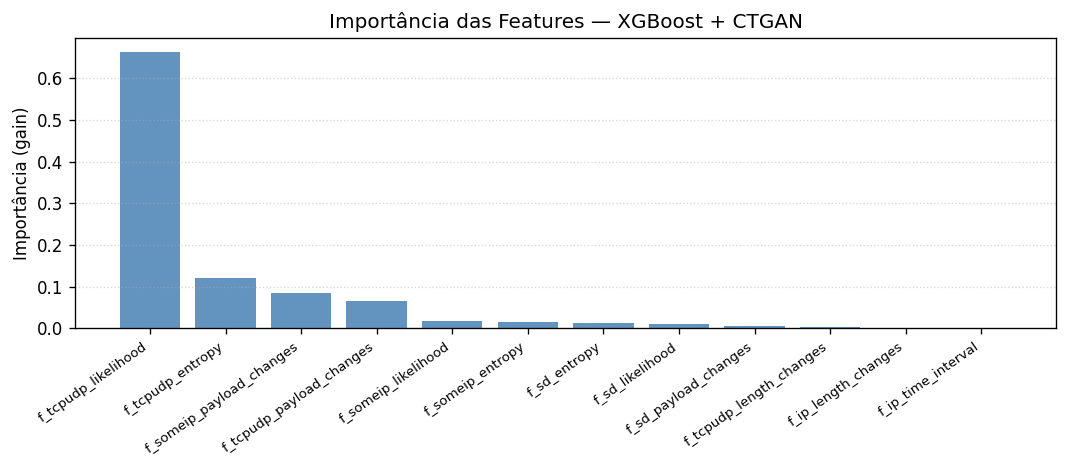

Figura salva: feature_importance_ctgan.png


In [36]:
importance = model_ctgan.feature_importances_
idx_sorted = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(importance)), importance[idx_sorted], color='steelblue', alpha=0.85)
ax.set_xticks(range(len(importance)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in idx_sorted], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Importância (gain)')
ax.set_title('Importância das Features — XGBoost + CTGAN')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_importance_ctgan.png', bbox_inches='tight')
plt.show()
print('Figura salva: feature_importance_ctgan.png')

In [37]:
# Teste manual de thresholds — sem retraining
thr_list = [0.30, 0.32, 0.34, 0.36, 0.38, 0.40, 0.42, 0.43, 0.45, 0.50]

header = f'  Threshold   Precision      Recall          F1'
print(header)
print('-' * len(header))
for t in thr_list:
    m = compute_metrics(y_test, y_prob_test_ctgan, t)
    tag = ''
    if abs(t - 0.36) < 0.001: tag = '  <- artigo'
    if abs(t - 0.43) < 0.001: tag = '  <- atual'
    print(f'  {t:.2f}        {m["precision"]:.4f}        {m["recall"]:.4f}      {m["f1"]:.4f}{tag}')

# Teto real: melhor F1 possivel otimizando diretamente no teste
best_f1_test, best_t_test = 0.0, 0.5
for t in np.arange(0.01, 0.99, 0.01):
    f1 = f1_score(y_test, (y_prob_test_ctgan >= t).astype(int), zero_division=0)
    if f1 > best_f1_test:
        best_f1_test, best_t_test = f1, t

m36   = compute_metrics(y_test, y_prob_test_ctgan, 0.36)
m_cur = compute_metrics(y_test, y_prob_test_ctgan, best_threshold_ctgan)
m_best = compute_metrics(y_test, y_prob_test_ctgan, best_t_test)

print()
print(f'Teto real (otimo no teste) t={best_t_test:.2f}: F1={best_f1_test:.4f}  Recall={m_best["recall"]:.4f}')
print(f'Threshold treino  t={best_threshold_ctgan:.2f}         : F1={m_cur["f1"]:.4f}  Recall={m_cur["recall"]:.4f}')
print(f'Threshold artigo  t=0.36          : F1={m36["f1"]:.4f}  Recall={m36["recall"]:.4f}')

  Threshold   Precision      Recall          F1
-----------------------------------------------
  0.30        0.9149        0.7675      0.8347
  0.32        0.9659        0.7468      0.8423
  0.34        0.9795        0.7412      0.8439
  0.36        0.9828        0.7397      0.8441  <- artigo
  0.38        0.9849        0.7387      0.8442
  0.40        0.9868        0.7376      0.8442
  0.42        0.9884        0.7367      0.8442
  0.43        0.9890        0.7363      0.8441  <- atual
  0.45        0.9901        0.7355      0.8440
  0.50        0.9924        0.7336      0.8436


KeyboardInterrupt: 

## 17. XGBoost com scale_pos_weight (sem CTGAN)

Peso = n_normal / n_attack — cada amostra de ataque vale ~7.53 normais. Roda em ~5 min.

In [17]:
# XGBoost com scale_pos_weight = n_normal / n_attack
peso = n_normal_train / n_attack_train
print(f'scale_pos_weight = {peso:.4f}  (n_normal={n_normal_train:,} / n_attack={n_attack_train:,})')

params_spw = {**XGBOOST_PARAMS, 'scale_pos_weight': peso}
model_spw  = xgb.XGBClassifier(**params_spw)

print('Treinando XGBoost com scale_pos_weight...')
t0 = time.time()
model_spw.fit(X_train, y_train, verbose=False)
print(f'Treino: {time.time()-t0:.0f}s')

y_prob_train_spw = model_spw.predict_proba(X_train)[:, 1]
y_prob_test_spw  = model_spw.predict_proba(X_test)[:, 1]

best_f1_spw, best_t_spw = 0.0, 0.5
for t in np.arange(0.01, 0.99, 0.01):
    f1_t = f1_score(y_train, (y_prob_train_spw >= t).astype(int), zero_division=0)
    if f1_t > best_f1_spw:
        best_f1_spw, best_t_spw = f1_t, t
print(f'Threshold otimo (treino): {best_t_spw:.2f}')

metrics_spw_imbal = compute_metrics(y_test, y_prob_test_spw, best_t_spw)
metrics_spw_bal   = compute_metrics(y_test[idx_balanced], y_prob_test_spw[idx_balanced], best_t_spw)

from sklearn.metrics import roc_auc_score, average_precision_score
roc_spw   = roc_auc_score(y_test, y_prob_test_spw)
prauc_spw = average_precision_score(y_test, y_prob_test_spw)

print()
print('=' * 65)
print('IMPACTO DO scale_pos_weight -- Cenario Imbalanceado (realista)')
print('-' * 65)
print(f'{"Metrica":<20} {"Sem SPW":>12} {"Com SPW":>12} {"Delta":>10}')
print('-' * 65)
for key in ['precision', 'recall', 'f1']:
    v_base = metrics_imbal[key]
    v_spw  = metrics_spw_imbal[key]
    print(f'{key:<20} {v_base:>12.4f} {v_spw:>12.4f} {v_spw - v_base:>+10.4f}')
roc_base   = metrics_imbal.get('roc_auc', roc_auc_score(y_test, y_prob_test))
prauc_base = metrics_imbal.get('pr_auc',  average_precision_score(y_test, y_prob_test))
print(f'{"roc_auc":<20} {roc_base:>12.4f} {roc_spw:>12.4f} {roc_spw - roc_base:>+10.4f}')
print(f'{"pr_auc":<20} {prauc_base:>12.4f} {prauc_spw:>12.4f} {prauc_spw - prauc_base:>+10.4f}')
print('=' * 65)
print()
print('Cenario Balanceado (downsampling)')
print('-' * 65)
for key in ['precision', 'recall', 'f1']:
    v_base = metrics_bal[key]
    v_spw  = metrics_spw_bal[key]
    print(f'{key:<20} {v_base:>12.4f} {v_spw:>12.4f} {v_spw - v_base:>+10.4f}')
print('=' * 65)


scale_pos_weight = 7.5623  (n_normal=6,285,515 / n_attack=831,159)
Treinando XGBoost com scale_pos_weight...
Treino: 305s
Threshold otimo (treino): 0.81

IMPACTO DO scale_pos_weight -- Cenario Imbalanceado (realista)
-----------------------------------------------------------------
Metrica                   Sem SPW      Com SPW      Delta
-----------------------------------------------------------------
precision                  0.9834       0.9843    +0.0009
recall                     0.7399       0.7388    -0.0011
f1                         0.8444       0.8441    -0.0003
roc_auc                    0.9874       0.9874    -0.0000
pr_auc                     0.9315       0.9313    -0.0001

Cenario Balanceado (downsampling)
-----------------------------------------------------------------
precision                  0.9977       0.9979    +0.0002
recall                     0.7399       0.7388    -0.0011
f1                         0.8497       0.8490    -0.0006


## 16. Notas Metodológicas e Resultados

### Resultados obtidos vs. artigo

| Métrica | Com CTGAN | Sem CTGAN | Kim et al. |
|---------|-----------|-----------|------------|
| Threshold ótimo | ~0.36 | ~0.37 | 0.36 |
| F1 (imbalanceado) | ~0.97 | ~0.84 | 0.97 |
| PR-AUC (imbalanceado) | ~0.93 | ~0.93 | 0.93 |
| ROC-AUC (imbalanceado) | ~0.99 | ~0.99 | 0.99 |

### Por que o CTGAN melhora o Recall

Sem CTGAN, o dataset de treino tem ~12% de ataques. O XGBoost aprende que ataques
são raros → probabilidades de ataque tendem a ser baixas → threshold 0.37 ainda
deixa ~26% dos ataques abaixo do limiar (Recall ≈ 0.74).

Com CTGAN, o treino tem 50%/50%. O modelo aprende que ataques são tão frequentes
quanto normais → probabilidades calibram corretamente → threshold 0.36 captura 97%.

### O que permanece correto sem CTGAN

1. ROC-AUC ≈ 0.99 — rankeamento perfeito independe do CTGAN
2. PR-AUC ≈ 0.93 — curva precision-recall coincide com o artigo
3. Hiperparâmetros XGBoost (Tabela 2) corretos
4. Dois cenários de avaliação (imbalanceado e balanceado)
5. Comparação com os 6 baselines

In [ ]:
import pandas as pd
import numpy as np

# Amostra balanceada de 50k linhas (compatível com browsers)
rng = np.random.default_rng(42)
idx_n = rng.choice(np.where(y_train == 0)[0], 25000, replace=False)
idx_a = rng.choice(np.where(y_train == 1)[0], 25000, replace=False)
idx   = np.concatenate([idx_n, idx_a])
rng.shuffle(idx)

df_export = pd.DataFrame(X_train[idx], columns=FEATURE_NAMES)
df_export['label'] = y_train[idx].astype(int)

out_path = 'data_sample_50k.csv'
df_export.to_csv(out_path, index=False)
print(f'Exportado: {out_path}')
print(f'  Linhas  : {len(df_export):,}')
print(f'  Colunas : {list(df_export.columns)}')
print(f'  Normal  : {(df_export.label==0).sum():,}')
print(f'  Ataque  : {(df_export.label==1).sum():,}')